In [1]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)
from xgboost import XGBClassifier
import matplotlib.pyplot as plt
import seaborn as sns

columns = [
    "duration","protocol_type","service","flag","src_bytes","dst_bytes",
    "land","wrong_fragment","urgent","hot","num_failed_logins","logged_in",
    "num_compromised","root_shell","su_attempted","num_root","num_file_creations",
    "num_shells","num_access_files","num_outbound_cmds","is_host_login",
    "is_guest_login","count","srv_count","serror_rate","srv_serror_rate",
    "rerror_rate","srv_rerror_rate","same_srv_rate","diff_srv_rate",
    "srv_diff_host_rate","dst_host_count","dst_host_srv_count",
    "dst_host_same_srv_rate","dst_host_diff_srv_rate","dst_host_same_src_port_rate",
    "dst_host_srv_diff_host_rate","dst_host_serror_rate","dst_host_srv_serror_rate",
    "dst_host_rerror_rate","dst_host_srv_rerror_rate","label","difficulty"
]

drop_cols = [
    "difficulty", "label",
    "srv_serror_rate", "dst_host_srv_serror_rate",
    "srv_rerror_rate", "dst_host_srv_rerror_rate",
]
categorical_cols = ["protocol_type", "service", "flag"]

In [2]:
train_df = pd.read_csv("../data/KDDTrain.txt", names=columns)
test_df  = pd.read_csv("../data/KDDTest.txt",  names=columns)

train_df["binary_label"] = train_df["label"].apply(lambda x: 0 if x == "normal" else 1)
test_df["binary_label"]  = test_df["label"].apply(lambda x: 0 if x == "normal" else 1)

train_df = train_df.drop(columns=drop_cols)
test_df  = test_df.drop(columns=drop_cols)

for col in categorical_cols:
    le = LabelEncoder()
    combined = pd.concat([train_df[col], test_df[col]], axis=0)
    le.fit(combined)
    train_df[col] = le.transform(train_df[col])
    test_df[col]  = le.transform(test_df[col])

X_train_raw = train_df.drop(columns=["binary_label"])
y_train      = train_df["binary_label"]
X_test_raw   = test_df.drop(columns=["binary_label"])
y_test       = test_df["binary_label"]

In [3]:
X_train = X_train_raw.copy()
X_test  = X_test_raw.copy()

X_train["src_bytes"] = np.log1p(X_train["src_bytes"])
X_train["dst_bytes"] = np.log1p(X_train["dst_bytes"])
X_test["src_bytes"]  = np.log1p(X_test["src_bytes"])
X_test["dst_bytes"]  = np.log1p(X_test["dst_bytes"])

In [4]:
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
spw = neg / pos
print(f"scale_pos_weight = {spw:.3f}  (negatives: {neg}, positives: {pos})")

scale_pos_weight = 1.149  (negatives: 67343, positives: 58630)


In [5]:
models = {
    "XGB baseline": XGBClassifier(
        n_estimators=100, max_depth=6, learning_rate=0.1,
        random_state=42, eval_metric="logloss", n_jobs=-1
    ),
    "XGB + log transform": XGBClassifier(
        n_estimators=100, max_depth=6, learning_rate=0.1,
        random_state=42, eval_metric="logloss", n_jobs=-1
    ),
    "XGB + class weight": XGBClassifier(
        n_estimators=100, max_depth=6, learning_rate=0.1,
        scale_pos_weight=spw,
        random_state=42, eval_metric="logloss", n_jobs=-1
    ),
    "XGB + all improvements": XGBClassifier(
        n_estimators=100, max_depth=8, learning_rate=0.1,
        scale_pos_weight=spw,
        random_state=42, eval_metric="logloss", n_jobs=-1
    ),
}

X_train_versions = {
    "XGB baseline":          X_train_raw,
    "XGB + log transform":   X_train,
    "XGB + class weight":    X_train_raw,
    "XGB + all improvements": X_train,
}
X_test_versions = {
    "XGB baseline":          X_test_raw,
    "XGB + log transform":   X_test,
    "XGB + class weight":    X_test_raw,
    "XGB + all improvements": X_test,
}

In [6]:
results = []
for name, model in models.items():
    Xtr = X_train_versions[name]
    Xte = X_test_versions[name]

    model.fit(Xtr, y_train)
    y_pred = model.predict(Xte)

    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec  = recall_score(y_test, y_pred)
    f1   = f1_score(y_test, y_pred)
    cm   = confusion_matrix(y_test, y_pred)

    print(f"\n=== {name} ===")
    print(f"Accuracy: {acc:.4f} | Precision: {prec:.4f} | Recall: {rec:.4f} | F1: {f1:.4f}")
    print("CM:", cm)

    results.append({"Model": name, "Accuracy": acc, "Precision": prec,
                    "Recall": rec, "F1": f1})


=== XGB baseline ===
Accuracy: 0.8079 | Precision: 0.9689 | Recall: 0.6846 | F1: 0.8023
CM: [[9429  282]
 [4048 8785]]

=== XGB + log transform ===
Accuracy: 0.8079 | Precision: 0.9689 | Recall: 0.6846 | F1: 0.8023
CM: [[9429  282]
 [4048 8785]]

=== XGB + class weight ===
Accuracy: 0.8116 | Precision: 0.9692 | Recall: 0.6910 | F1: 0.8068
CM: [[9429  282]
 [3965 8868]]

=== XGB + all improvements ===
Accuracy: 0.8035 | Precision: 0.9681 | Recall: 0.6770 | F1: 0.7968
CM: [[9425  286]
 [4145 8688]]




=== FULL COMPARISON TABLE ===
                 Model  Accuracy  Precision   Recall       F1
          XGB baseline  0.807931   0.968898 0.684563 0.802283
   XGB + log transform  0.807931   0.968898 0.684563 0.802283
    XGB + class weight  0.811613   0.969180 0.691031 0.806805
XGB + all improvements  0.803451   0.968130 0.677005 0.796808


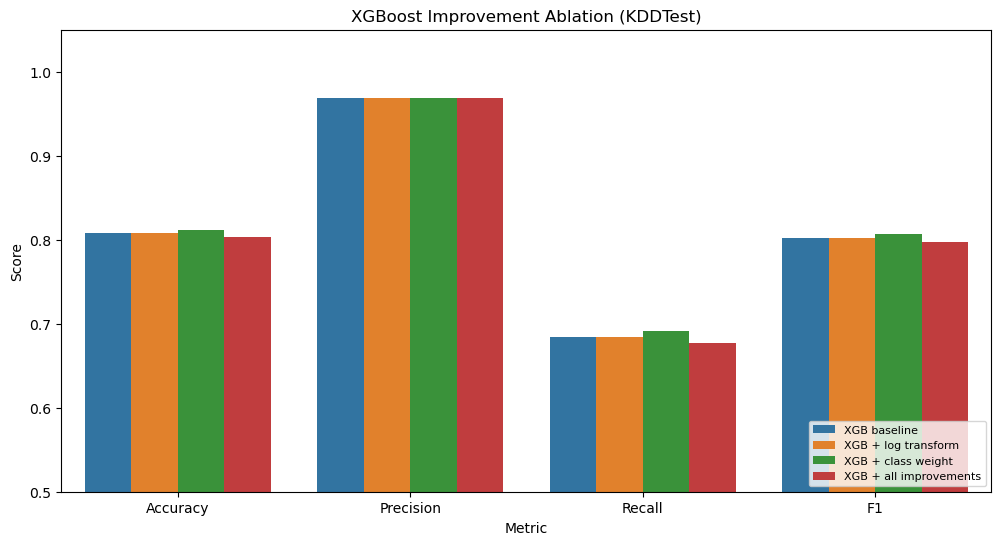

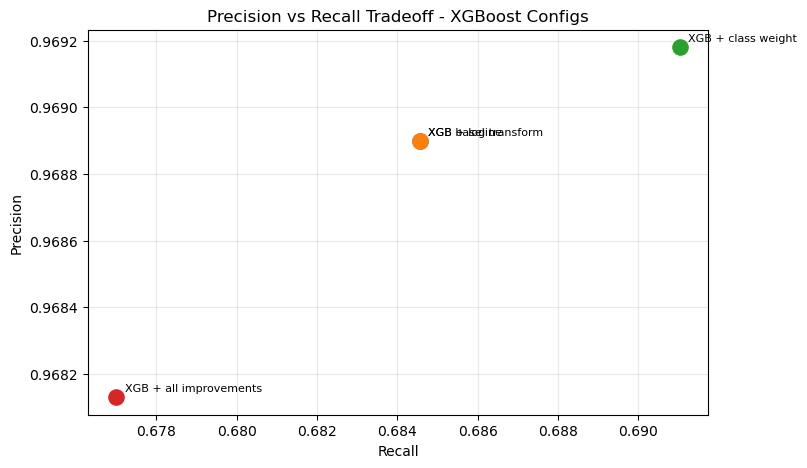

In [7]:
comparison = pd.DataFrame(results)
print("\n\n=== FULL COMPARISON TABLE ===")
print(comparison.to_string(index=False))

melted = comparison.melt(id_vars="Model", var_name="Metric", value_name="Score")
plt.figure(figsize=(12, 6))
sns.barplot(data=melted, x="Metric", y="Score", hue="Model")
plt.title("XGBoost Improvement Ablation (KDDTest)")
plt.ylim(0.5, 1.05)
plt.legend(loc="lower right", fontsize=8)

plt.figure(figsize=(8, 5))
for _, row in comparison.iterrows():
    plt.scatter(row["Recall"], row["Precision"], s=120, zorder=5)
    plt.annotate(row["Model"], (row["Recall"], row["Precision"]),
                 textcoords="offset points", xytext=(6, 4), fontsize=8)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision vs Recall Tradeoff - XGBoost Configs")
plt.grid(True, alpha=0.3)